# Digital Loneliness and Social Media Usage Among Teenagers
---
### Opening Question
**How does usage of social media for prolonged periods affect sleep patterns, anxiety and stress levels, academic performance, physical activity, and depression indicators among adolescents?**

### Objective
To find patterns and connections between online presence and mental wellbeing in teenagers. 
Instead of assuming causes, I've explored correlations, distributions, and typical behaviours to understand the complex link between use of tech and teenage mental health.

### Dataset Overview
- **Sample Size**: Dataset taken from [Kaggle](https://www.kaggle.com/datasets/algozee/teenager-menthal-healy/discussion/691716).
- **Variables**: age, gender, daily_social_media_hours, platform_usage, sleep_hours, screen_time_before_sleep, academic_performance, physical_activity, social_interaction_level, stress_level, anxiety_level, addiction_level, depression_label
- **Analysis Approach**: Exploratory Data Analysis [EDA], focusing on descriptive insights and pattern recognition through visualisations and summary statistics.


In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10


In [144]:
# colour scheme
primary = "#351F7D"
secondary = "#C4A3CE"

gradient = ["#C4A3CE", "#B18CC4", "#9D75BA", "#895EB0", "#7647A5", "#62309B", "#4F1990", "#351F7D"]

# accent colours
redacc = "#E74C3C"
greenacc = "#27AE60"
blueacc = "#3498DB"


### 1. What does the dataset look like at first glance?

To start off this report, I'll begin by loading the dataset and taking a look at its structure, size, and main features. This helps me get an initial look at what to expect of this dataset, and spend the next 5 minutes regretting my life decisions.

In [145]:
# load the dataset
path = "mentalhealth.csv"
file = pd.read_csv(path)

In [146]:
print(f"Dataset shape: {file.shape}")

Dataset shape: (1200, 13)


In [147]:
print(f"Total records: {file.shape[0]}")

Total records: 1200


In [148]:
print(f"Total columns: {file.shape[1]}")

Total columns: 13


### 1.1 Display of Records
Printing the first and last five records of data to understand its structure better.

In [149]:
print("First 5 records:")
file.head()

First 5 records:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,YouTube,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,YouTube,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [150]:
print("Last 5 records:")
file.tail()

Last 5 records:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,YouTube,6.5,1.0,2.91,0.9,medium,5,7,3,0


### 1.2 Data Types and Column Information
Looking at the technical details: variable types and column names.

In [151]:
print("Dataset Info:")
file.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [152]:
print("Column Names:")
file.columns.tolist()

Column Names:


['age',
 'gender',
 'daily_social_media_hours',
 'platform_usage',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'social_interaction_level',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label']

### Observations

- **Nice Data**: Its just data.
- **Good Programmer**: My codes... work?

**What this suggests**: Data is nice and the programmer is not bad at his one job. Huge applause.

### 2. Is the data good enough... or will I spend the next 30 minutes fixing stuff?

Before starting the analysis, I need to check if the data is complete and clean. This includes looking for missing values, duplicates, and any obvious errors, which may have occurred by the brilliant person I siphoned this dataset off. 


In [153]:
# missing values check
print("Missing Values:")
missing = file.isnull().sum()
missing_pct = (missing / len(file)) * 100
missing_file = pd.DataFrame({"Column": missing.index, "Missing Count": missing.values, "Missing %": missing_pct.values})
print(missing_file[missing_file["Missing Count"] > 0] if missing_file["Missing Count"].sum() > 0 else "No missing values found!")
print(f"Total missing values in dataset: {file.isnull().sum().sum()}")

Missing Values:
No missing values found!
Total missing values in dataset: 0


In [154]:
# duplicates check
print(f"Number of duplicate rows: {file.duplicated().sum()}")
print(f"Number of unique records: {len(file.drop_duplicates())}")

Number of duplicate rows: 0
Number of unique records: 1200


In [155]:
# summary of variables
print("Dataset Statistics:")
file.describe(include="all").round(2)

Dataset Statistics:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.00,1200,1200.00,1200,1200.00,1200.00,1200.00,1200.00,1200,1200.00,1200.00,1200.00,1200.00
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.93,NaN,4.54,NaN,6.45,1.74,2.99,1.01,NaN,5.45,5.64,5.56,0.03
std,2.02,NaN,2.03,NaN,1.44,0.72,0.58,0.58,NaN,2.90,2.86,2.83,0.16
min,13.00,NaN,1.00,NaN,4.00,0.50,2.00,0.00,NaN,1.00,1.00,1.00,0.00
25%,14.00,NaN,2.80,NaN,5.20,1.10,2.50,0.50,NaN,3.00,3.00,3.00,0.00
50%,16.00,NaN,4.50,NaN,6.50,1.80,2.99,1.00,NaN,5.00,6.00,6.00,0.00
75%,18.00,NaN,6.30,NaN,7.60,2.40,3.48,1.50,NaN,8.00,8.00,8.00,0.00


### Observations

- **Data Completeness**: Thankfully, no missing values were found. My job is much easier now, since the data is ready for analysis
- **Data Integrity**: No duplicate records present in the dataset
- **Data Types**: Most variables, which are to directly worked on, are numeric, apart from the obvious ones like gender and platform_usage
- **Age Range**: The teenagers in this dataset range from early to late adolescence [roughly 13 to 21 years old]

**What this suggests**: The dataset is well-structured and does not need any cleaning or filling of missing values. Big dubs.

### 3. How *average* is the Average Teenager?
Now, presenting the statistics of the average adolescent in this dataset. I've calculated the values using the mean() function. Pretty straightforward, and standard.


In [156]:
avg_profile = {
    "Average Age": file["age"].mean(),
    "Average Sleep Hours": file["sleep_hours"].mean(),
    "Average Daily Social Media Hours": file["daily_social_media_hours"].mean(),
    "Average Screen Time Before Sleep [min]": file["screen_time_before_sleep"].mean(),
    "Average Physical Activity Hours": file["physical_activity"].mean(),
    "Average Stress Level": file["stress_level"].mean(),
    "Average Anxiety Level": file["anxiety_level"].mean(),
    "Average Addiction Level": file["addiction_level"].mean(),
}

profile_file = pd.DataFrame(avg_profile, index=["Dataset Average"]).round(2)
profile_file.T

,Dataset Average
Average Age,15.93
Average Sleep Hours,6.45
Average Daily Social Media Hours,4.54
Average Screen Time Before Sleep [min],1.74
Average Physical Activity Hours,1.01
Average Stress Level,5.45
Average Anxiety Level,5.64
Average Addiction Level,5.56


### Observations
- **Social Media Addiction**: The average teenager in this dataset spends around five hours a day on social media, sleeps less than eight hours, and reports moderate stress and anxiety levels. Now that's something your teachers will love speaking to your parents about in the open house, or the PTM. Whichever comes first.
- **Less Sleep = Brain Tired**: The typical teenager here is a heavy digital user with below ideal sleep and moderate to bad mental health scores. Nothing else to say except for "real".

**What this suggests**: We're cooked.

### 4. How often do Teenagers use Social Media?

Social media has become a regular part of daily life for many [read: all] teenagers. Let me look at which platforms *we* prefer, time spent, and whether usage differs by age or gender. 

**Questions for This Section:**
- Which platforms are most common among teenagers?
- How many hours do they typically spend on social media each day?
- Do usage patterns change with age or gender?

### 4.1 Platform Preferences

Before I present the demographics, please take a wild guess.

In [157]:
print("Platform Usage Distribution:")
platform_counts = file["platform_usage"].value_counts()
print(platform_counts)
print(f"\nPercentage Distribution:")
print((platform_counts / len(file) * 100).round(1))

Platform Usage Distribution:
platform_usage
Instagram    411
YouTube      398
Both         391
Name: count, dtype: int64

Percentage Distribution:
platform_usage
Instagram    34.2
YouTube      33.2
Both         32.6
Name: count, dtype: float64


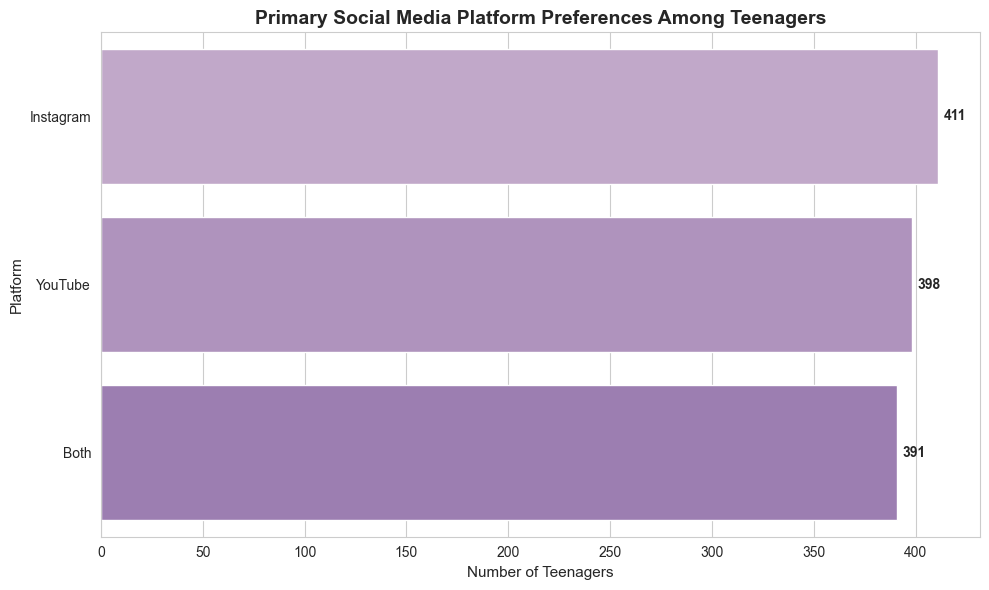

In [158]:
# visualisation: platform popularity
plt.figure(figsize=(10, 6))
ax = sns.countplot(y="platform_usage", data=file, order=file["platform_usage"].value_counts().index, palette=gradient, hue="platform_usage", legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10, fontweight="bold")

plt.title("Primary Social Media Platform Preferences Among Teenagers", fontsize=14, fontweight="bold")
plt.xlabel("Number of Teenagers", fontsize=11)
plt.ylabel("Platform", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Sorted Priorities**: Instagram and YouTube, after all. Many even use both. Well we do have our priorities sorted, what about you, Hermione?

**What this suggests**: Hermione Granger has something to learn from the Muggles, after all.


### 4.2 Daily Social Media Usage Distribution

Looking at the spread and average of daily social media hours. Parents, please look away.


In [159]:
print("Daily Social Media Usage Statistics:")
print(file["daily_social_media_hours"].describe().round(2))

Daily Social Media Usage Statistics:
count    1200.00
mean        4.54
std         2.03
min         1.00
25%         2.80
50%         4.50
75%         6.30
max         8.00
Name: daily_social_media_hours, dtype: float64


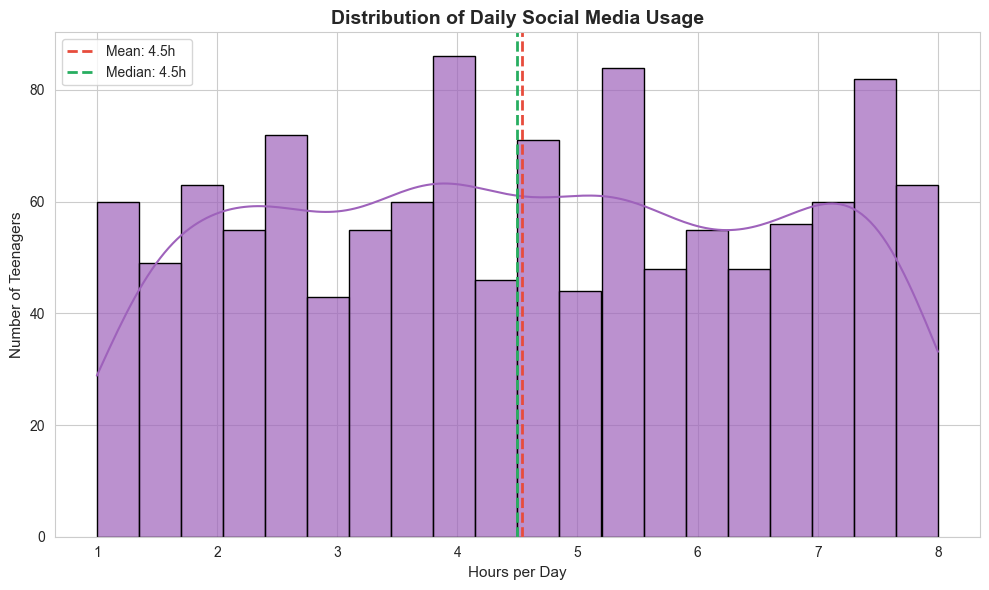

In [160]:
# visualisation: Usage distribution
plt.figure(figsize=(10, 6))
sns.histplot(file["daily_social_media_hours"], bins=20, kde=True, color="#9E62BB", edgecolor="black", alpha=0.7)

plt.axvline(file["daily_social_media_hours"].mean(), color=redacc, linestyle="--", linewidth=2, label=f"Mean: {file["daily_social_media_hours"].mean():.1f}h")
plt.axvline(file["daily_social_media_hours"].median(), color=greenacc, linestyle="--", linewidth=2, label=f"Median: {file["daily_social_media_hours"].median():.1f}h")

plt.title("Distribution of Daily Social Media Usage", fontsize=14, fontweight="bold")
plt.xlabel("Hours per Day", fontsize=11)
plt.ylabel("Number of Teenagers", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


### Observations
- **Surprise, surprise**: The average usage of social media lies at around 4.5 hours a day, while there are a substantial amount of extreme numbers lying around more than 5 hours of daily social media usage. 

**What this suggests**: Please touch grass.

### 4.3 Usage by Age Group

Seeing whether usage patterns change as teenagers get older. It doesn't.


In [161]:
# Create age groups
file["age_group"] = pd.cut(file["age"], bins=[12, 15, 18, 21], labels=["13-15", "16-18", "19-21"])

print("Average Social Media Usage by Age Group:")
age_usage = file.groupby("age_group")["daily_social_media_hours"].agg(["mean", "median", "std", "count"]).round(2)
print(age_usage)

Average Social Media Usage by Age Group:
           mean  median   std  count
age_group                           
13-15      4.53     4.4  2.01    533
16-18      4.55     4.5  2.05    505
19-21      4.52     4.6  2.06    162


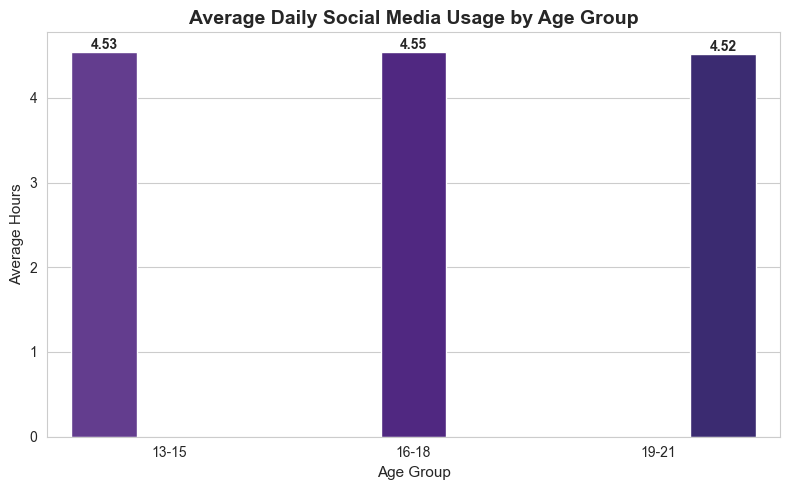

In [162]:
# visualisation: age group comparison
plt.figure(figsize=(8, 5))
age_means = file.groupby("age_group")["daily_social_media_hours"].mean()
ax = sns.barplot(x=age_means.index, y=age_means.values, palette=gradient[-3:], hue=age_means.index, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=10, fontweight="bold")

plt.title("Average Daily Social Media Usage by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Average Hours", fontsize=11)
plt.tight_layout()
plt.show()


### Observation
- **Not much of a change**: Social media usage doesn't vary a lot by age groups. The graph displays a consistent amount of usage.

**What this suggests**: It cannot be conclusive that all the time spent is just recreational. Social media has also transitioned to become a large contender for users across all ages to interact, display products, and allow for better networking opportunities. Much better than LinkedIn. Therefore, it would be wrong to conclude that all daily hours of usage is purely to induce fast gained dopamine.

### 4.4 Usage by Gender

Comparing social media habits across different gender groups. Important demographic to scout out all of our little misogynists and misandrists. [no offense pls dont cancel]


In [163]:
print("Average Social Media Usage by Gender:")
gender_usage = file.groupby("gender")["daily_social_media_hours"].agg(["mean", "median", "std", "count"]).round(2)
print(gender_usage)


Average Social Media Usage by Gender:
        mean  median   std  count
gender                           
female  4.51     4.4  2.04    585
male    4.56     4.6  2.02    615


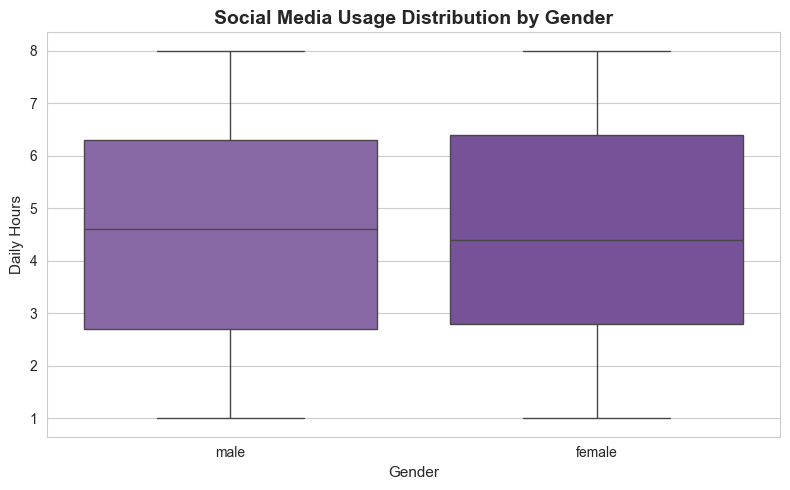

In [164]:
# visualisation: Gender comparison
plt.figure(figsize=(8, 5))
sns.boxplot(x="gender", y="daily_social_media_hours", data=file, palette=gradient[3:5], hue="gender", legend=False)

plt.title("Social Media Usage Distribution by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=11)
plt.ylabel("Daily Hours", fontsize=11)
plt.tight_layout()
plt.show()


### Observation
- **r/girlsarentreal**: There is negligible difference in the usage by gender, but Females show slightly higher numbers. Now we know why Taylor Swift is so famous. [do swifties use github]

**What this suggests**: r/girlsarentreal is propaganda?

### 4.5 Average Usage by Platform
Comparing average daily hours for teenagers who named each platform as their primary choice. There shouldn't be a lot of difference, but here we go.

In [165]:
print("Average Daily Social Media Hours by Primary Platform:")
platform_hours = file.groupby("platform_usage")["daily_social_media_hours"].agg(["mean", "median", "count"]).round(2)
platform_hours_sorted = platform_hours.sort_values("mean", ascending=False)
print(platform_hours_sorted)


Average Daily Social Media Hours by Primary Platform:
                mean  median  count
platform_usage                     
Instagram       4.56     4.4    411
YouTube         4.53     4.6    398
Both            4.52     4.5    391


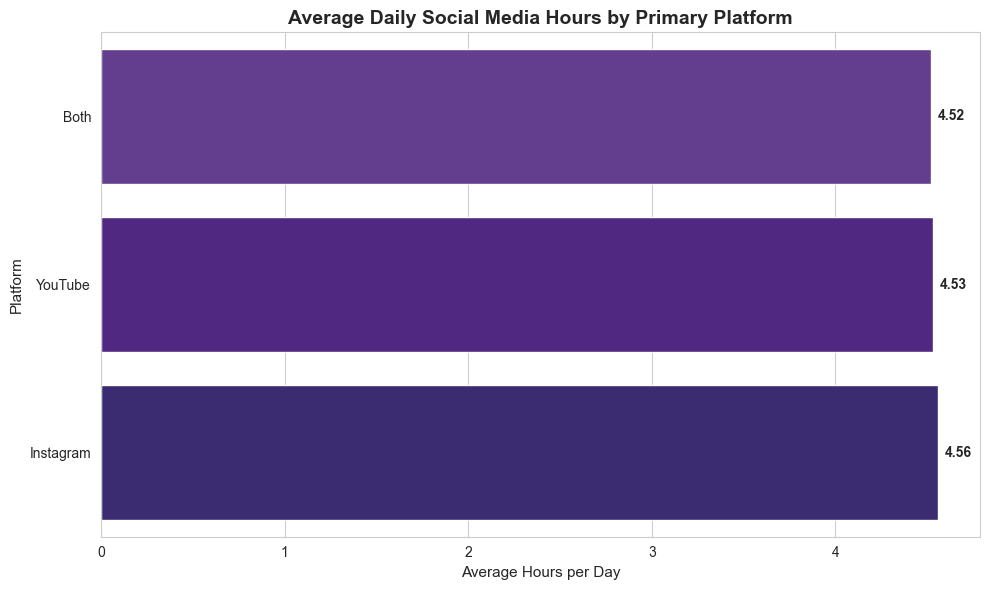

In [166]:
# visualisation: Platform average usage
plt.figure(figsize=(10, 6))
platform_means = file.groupby("platform_usage")["daily_social_media_hours"].mean().sort_values(ascending=True)
ax = sns.barplot(y=platform_means.index, x=platform_means.values, palette=gradient[-len(platform_means):], hue=platform_means.index, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=10, fontweight="bold", padding=5)

plt.title("Average Daily Social Media Hours by Primary Platform", fontsize=14, fontweight="bold")
plt.xlabel("Average Hours per Day", fontsize=11)
plt.ylabel("Platform", fontsize=11)
plt.tight_layout()
plt.show()


### Observations
- **Reels over Shorts**: Although the difference is pretty low, Instagram still emerges as the preferred platform over YouTube.

**What this suggests**: You're ought to get more famous on Instagram. Go ahead, make that account.

### 5. Are the bags under our eyes Gucci?
Sleep is really important for teenagers' health and development [joke]. This section looks at how screen time before bed relates to sleep duration. Blue light is known to cause issues with the circadian rhythm, this analysis aims to test the motion.

**Questions for This Section**:
- What are the usual sleep patterns in this group?
- How does social media use relate to how much sleep teenagers get?
- Does screen time just before bed affect sleep?

How much are teenagers actually sleeping? Rhetorical question.


In [167]:
print("Sleep Hours Statistics:")
sleep_stats = file["sleep_hours"].describe().round(2)
print(sleep_stats)

print(f"\nPercentage sleeping <7 hours [below recommended]: {(file[file["sleep_hours"] < 7].shape[0] / len(file) * 100):.1f}%")
print(f"Percentage sleeping 7-9 hours [recommended]: {(file[(file["sleep_hours"] >= 7) & (file["sleep_hours"] <= 9)].shape[0] / len(file) * 100):.1f}%")
print(f"Percentage sleeping >9 hours: {(file[file["sleep_hours"] > 9].shape[0] / len(file) * 100):.1f}%")


Sleep Hours Statistics:
count    1200.00
mean        6.45
std         1.44
min         4.00
25%         5.20
50%         6.50
75%         7.60
max         9.00
Name: sleep_hours, dtype: float64

Percentage sleeping <7 hours [below recommended]: 60.1%
Percentage sleeping 7-9 hours [recommended]: 39.9%
Percentage sleeping >9 hours: 0.0%


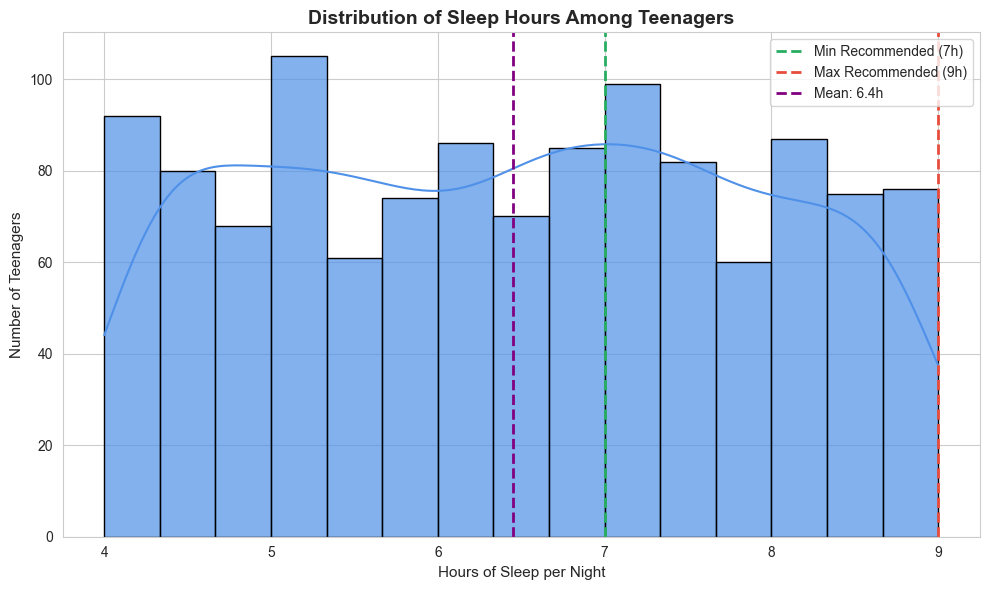

In [168]:
# visualisation: sleep distribution
plt.figure(figsize=(10, 6))
sns.histplot(file["sleep_hours"], bins=15, kde=True, color="#4F90E8", edgecolor="black", alpha=0.7)

plt.axvline(7, color=greenacc, linestyle="--", linewidth=2, label="Min Recommended (7h)")
plt.axvline(9, color=redacc, linestyle="--", linewidth=2, label="Max Recommended (9h)")
plt.axvline(file["sleep_hours"].mean(), color="purple", linestyle="--", linewidth=2, label=f"Mean: {file["sleep_hours"].mean():.1f}h")

plt.title("Distribution of Sleep Hours Among Teenagers", fontsize=14, fontweight="bold")
plt.xlabel("Hours of Sleep per Night", fontsize=11)
plt.ylabel("Number of Teenagers", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


### Observations
- **Low sleep levels**: A noticeable number of teenagers in this dataset sleep less than the recommended 7-9 hours. A small price to pay, for salvation [read: an hour of reels].

**What this suggests**: Lack of sleep is known to increase the risk of poor mental health, which most teenagers are at a risk of, citing the levels of academic and social pressure, astronomically high levels of low self-esteem being observed, among others. Below-ideal sleep hours act as exhibitors to the core problem.

### 5.1 Social Media Usage vs. Sleep Duration
Checking whether there is a correlation between daily social media and sleep hours.

In [169]:
# correlation calc
corr_media_sleep = file["daily_social_media_hours"].corr(file["sleep_hours"])
print(f"Correlation between daily social media usage and sleep hours: {corr_media_sleep:.3f}")


Correlation between daily social media usage and sleep hours: -0.009


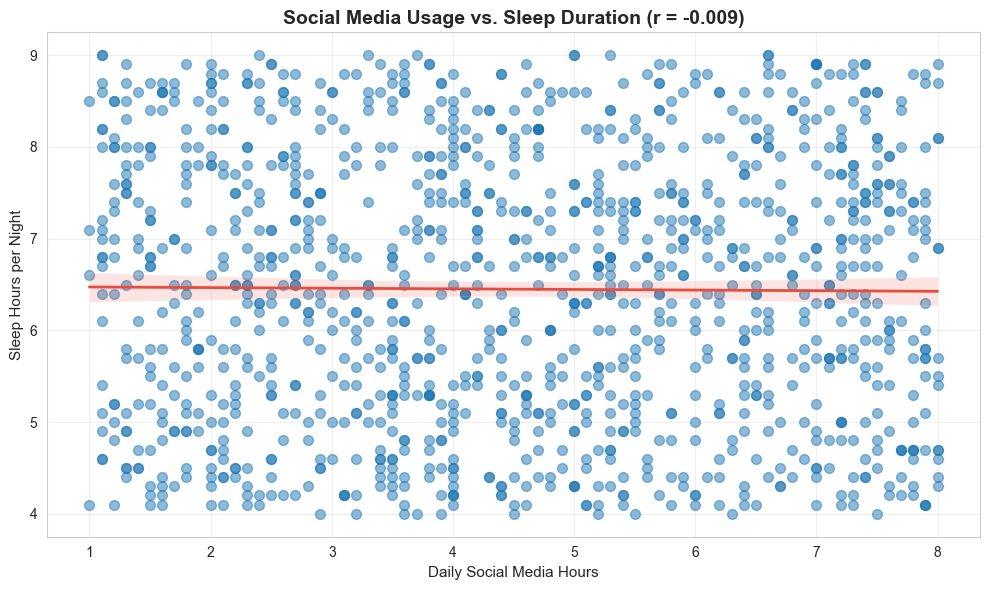

In [170]:
# visualisation: scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(x="daily_social_media_hours", y="sleep_hours", data=file, scatter_kws={"alpha": 0.5, "s": 50}, line_kws={"color": redacc, "linewidth": 2})

plt.title(f"Social Media Usage vs. Sleep Duration (r = {corr_media_sleep:.3f})", fontsize=14, fontweight="bold")
plt.xlabel("Daily Social Media Hours", fontsize=11)
plt.ylabel("Sleep Hours per Night", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Observations
- **Sleep and Social Media**: If the correlation is negative, that would suggest that teenagers who spend more time on social media tend to sleep fewer hours. However, other factors [like when they use it or what they do on it] also matter.

**What this suggests**: Social media use and sleep are linked, but the relationship is not simple cause and effect. Individual habits probably play a big role.

### 5.2 Pre-Sleep Screen Time Impact

Looking specifically at screen time in the minutes before bed and how it relates to sleep duration.


In [171]:
print("Pre-Sleep Screen Time Statistics (minutes):")
print(file["screen_time_before_sleep"].describe().round(2))

# correlation
corr_screen_sleep = file["screen_time_before_sleep"].corr(file["sleep_hours"])
print(f"\nCorrelation between pre-sleep screen time and sleep duration: {corr_screen_sleep:.3f}")


Pre-Sleep Screen Time Statistics (minutes):
count    1200.00
mean        1.74
std         0.72
min         0.50
25%         1.10
50%         1.80
75%         2.40
max         3.00
Name: screen_time_before_sleep, dtype: float64

Correlation between pre-sleep screen time and sleep duration: 0.010


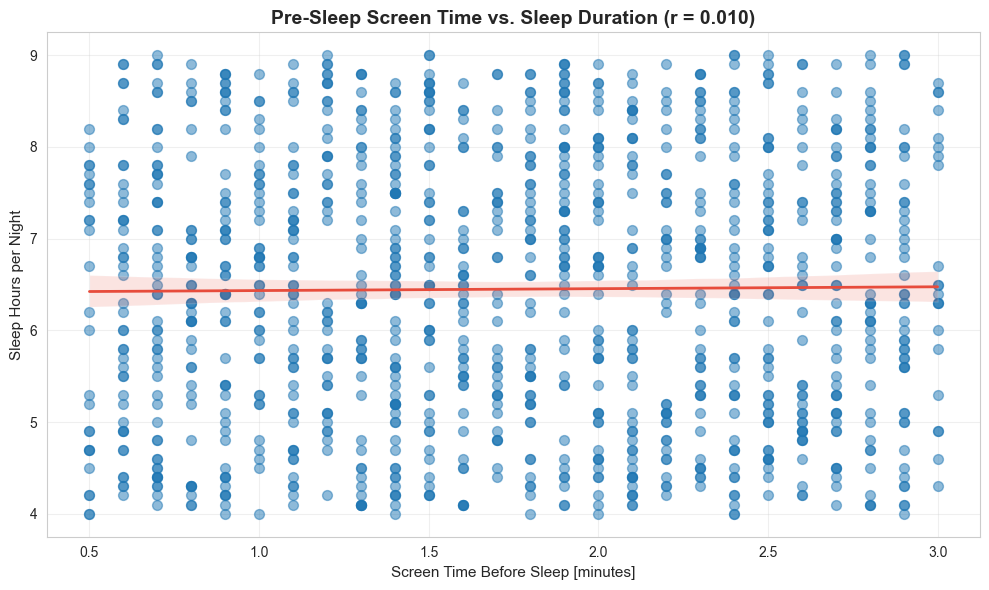

In [172]:
# visualisation: pre-sleep screen mins vs sleep hrs
plt.figure(figsize=(10, 6))
sns.regplot(x="screen_time_before_sleep", y="sleep_hours", data=file, scatter_kws={"alpha": 0.5, "s": 50}, line_kws={"color": redacc, "linewidth": 2})

plt.title(f"Pre-Sleep Screen Time vs. Sleep Duration (r = {corr_screen_sleep:.3f})", fontsize=14, fontweight="bold")
plt.xlabel("Screen Time Before Sleep [minutes]", fontsize=11)
plt.ylabel("Sleep Hours per Night", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
- **Sleep vs Screen Time**: Using screens right before bed can affect sleep because of blue light and mental stimulation. If the correlation here is negative, it would mean that more pre-sleep screen time is linked to fewer hours of sleep.

**What this suggests**: Pre-sleep screen time is something that could be changed more easily than total daily social media use. Encouraging teenagers to put screens away before bed might be a practical way to improve sleep.

### 6. How is Stress and Anxiety Relevant?
Stress and anxiety are often talked about in connection with social media. This section looks at the levels teenagers report and how they relate to digital habits.

**Questions**:
- What stress and anxiety levels do teenagers report?
- How does social media use relate to stress and anxiety?
How common are stress and anxiety in this group?


In [173]:
print("Stress Level Statistics:")
file["stress_level"].describe().round(2)


Stress Level Statistics:


count    1200.00
mean        5.45
std         2.90
min         1.00
25%         3.00
50%         5.00
75%         8.00
max        10.00
Name: stress_level, dtype: float64

In [174]:
print("Anxiety Level Statistics:")
file["anxiety_level"].describe().round(2)

Anxiety Level Statistics:


count    1200.00
mean        5.64
std         2.86
min         1.00
25%         3.00
50%         6.00
75%         8.00
max        10.00
Name: anxiety_level, dtype: float64

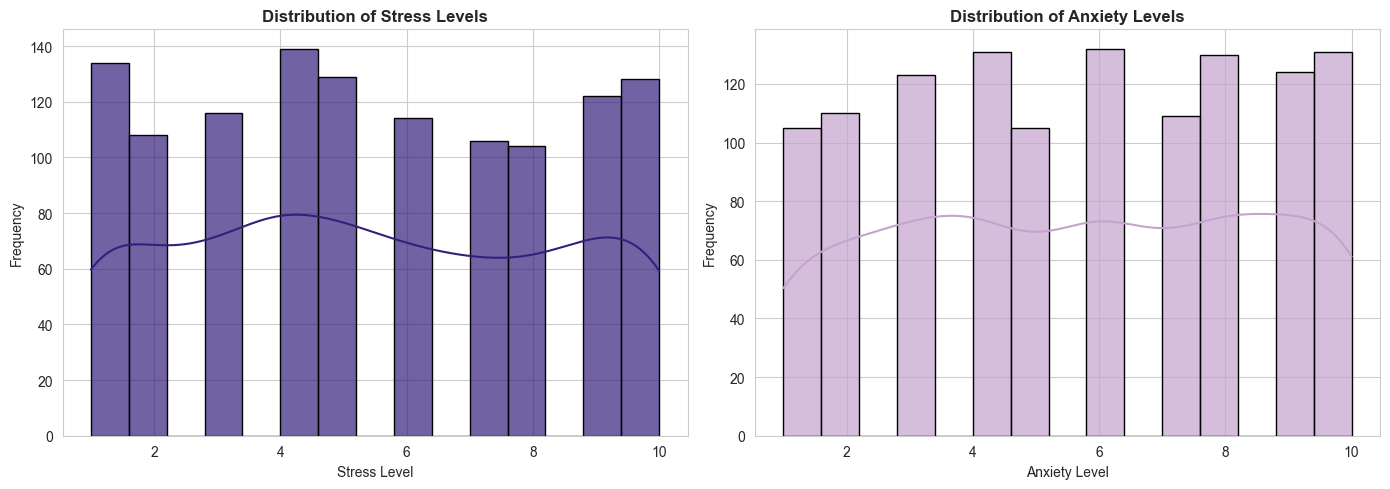

In [175]:
# visualisation: stress distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(file["stress_level"], bins=15, kde=True, color=primary, ax=axes[0], alpha=0.7, edgecolor="black")
axes[0].set_title("Distribution of Stress Levels", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Stress Level", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)

sns.histplot(file["anxiety_level"], bins=15, kde=True, color=secondary, ax=axes[1], alpha=0.7, edgecolor="black")
axes[1].set_title("Distribution of Anxiety Levels", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Anxiety Level", fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)

plt.tight_layout()
plt.show()


### 6.1 Social Media Usage vs. Stress

Finding the correlation between daily social media hours and stress/anxiety levels.

In [176]:
corr_media_stress = file["daily_social_media_hours"].corr(file["stress_level"])
print(f"Correlation between social media usage and stress: {corr_media_stress:.3f}")


Correlation between social media usage and stress: 0.031


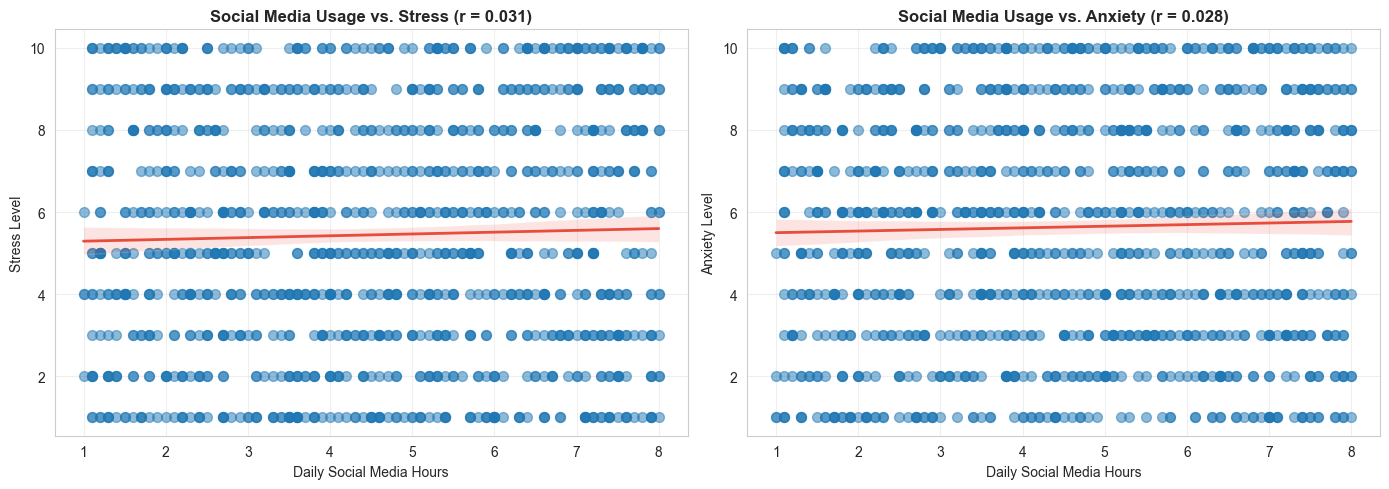

In [177]:
# visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    x="daily_social_media_hours",
    y="stress_level",
    data=file,
    scatter_kws={"alpha": 0.5, "s": 50},
    line_kws={"color": redacc, "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title(f"Social Media Usage vs. Stress (r = {corr_media_stress:.3f})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Daily Social Media Hours", fontsize=10)
axes[0].set_ylabel("Stress Level", fontsize=10)
axes[0].grid(True, alpha=0.3)

corr_media_anxiety = file["daily_social_media_hours"].corr(file["anxiety_level"])
sns.regplot(
    x="daily_social_media_hours",
    y="anxiety_level",
    data=file,
    scatter_kws={"alpha": 0.5, "s": 50},
    line_kws={"color": redacc, "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title(f"Social Media Usage vs. Anxiety (r = {corr_media_anxiety:.3f})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Daily Social Media Hours", fontsize=10)
axes[1].set_ylabel("Anxiety Level", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Observations
- **Direct Proportionality**: If the correlations are positive, that would mean teenagers who spend more time on social media also report higher stress and anxiety. But this does not prove that social media causes stress. It could also be that stressed or anxious teenagers turn to social media for distraction or comfort.

**What this suggests**: The connection between social media and mental health is probably two-way. This dataset can only show association, not causation. To really understand the direction, we would need different types of studies [like experiments or long-term tracking].

### 7. Does usage of social media affect school grades?
 This section looks at the relationship between digital habits and academic performance.

**Questions**:
- How does social media use correlate with academic performance?
- Does addiction level play a role in this relationship?
Is academic performance linked to digital habits?


In [178]:
print("Academic Performance Statistics:")
print(file["academic_performance"].describe().round(2))


Academic Performance Statistics:
count    1200.00
mean        2.99
std         0.58
min         2.00
25%         2.50
50%         2.99
75%         3.48
max         4.00
Name: academic_performance, dtype: float64


In [179]:
# correlation analyses
corr_media_academic = file["daily_social_media_hours"].corr(file["academic_performance"])
corr_addiction_academic = file["addiction_level"].corr(file["academic_performance"])

print(f"Correlation between social media usage and academic performance: {corr_media_academic:.3f}")
print(f"Correlation between addiction level and academic performance: {corr_addiction_academic:.3f}")


Correlation between social media usage and academic performance: 0.013
Correlation between addiction level and academic performance: 0.029


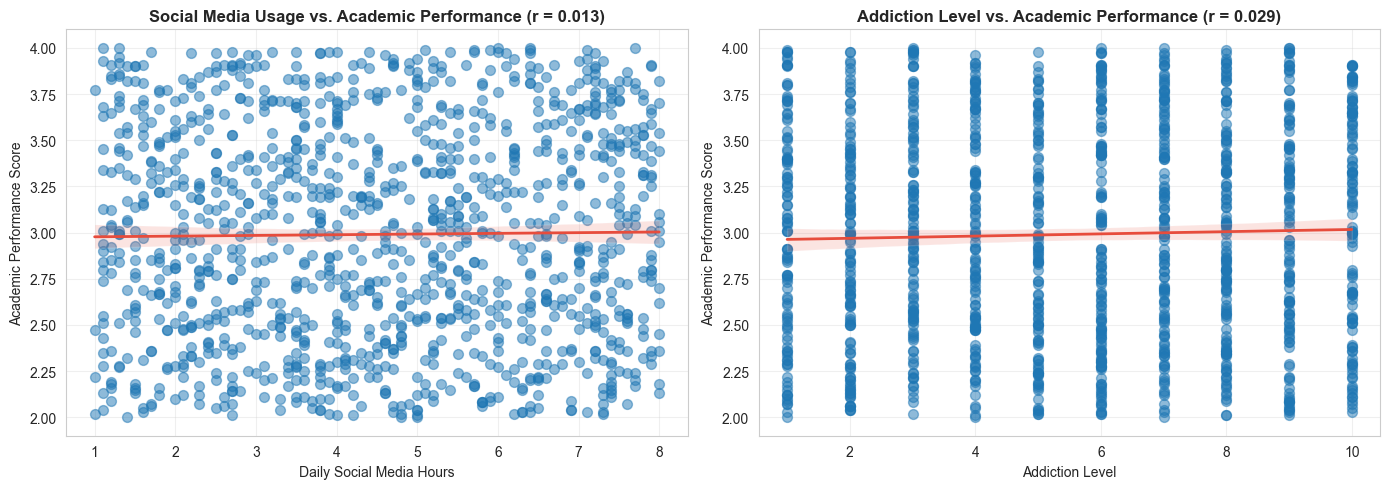

In [180]:
# visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x="daily_social_media_hours", y="academic_performance", data=file, scatter_kws={"alpha": 0.5, "s": 50}, line_kws={"color": redacc, "linewidth": 2}, ax=axes[0])
axes[0].set_title(f"Social Media Usage vs. Academic Performance (r = {corr_media_academic:.3f})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Daily Social Media Hours", fontsize=10)
axes[0].set_ylabel("Academic Performance Score", fontsize=10)
axes[0].grid(True, alpha=0.3)

sns.regplot(x="addiction_level", y="academic_performance", data=file, scatter_kws={"alpha": 0.5, "s": 50}, line_kws={"color": redacc, "linewidth": 2}, ax=axes[1])
axes[1].set_title(f"Addiction Level vs. Academic Performance (r = {corr_addiction_academic:.3f})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Addiction Level", fontsize=10)
axes[1].set_ylabel("Academic Performance Score", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Observations
- **Academic performance vs Screen Time**: Negative correlations indicate that more social media use or higher addiction scores are linked to lower academic performance. This could be because screen time takes time away from studying or makes it harder to concentrate.

**What this suggests**: Academic performance might be one of the clearer costs of heavy digital engagement. The data suggests that time spent online may compete directly with schoolwork and focused study time.


### 8. Physical Activity Analysis

Physical activity is important for teenage health. This section looks at whether screen time is linked to lower levels of exercise.

**Questions**:
- Does more social media use mean less physical activity?
- How strong is the relationship between screen time and exercise?

Are digital habits replacing physical ones? Let's see if social media use and physical activity are related.

In [181]:
print("Physical Activity Statistics [hours per day]:")
file["physical_activity"].describe().round(2)

Physical Activity Statistics [hours per day]:


count    1200.00
mean        1.01
std         0.58
min         0.00
25%         0.50
50%         1.00
75%         1.50
max         2.00
Name: physical_activity, dtype: float64

In [182]:
corr_media_activity = file["daily_social_media_hours"].corr(file["physical_activity"])
print(f"\nCorrelation between social media usage and physical activity: {corr_media_activity:.3f}")


Correlation between social media usage and physical activity: 0.026


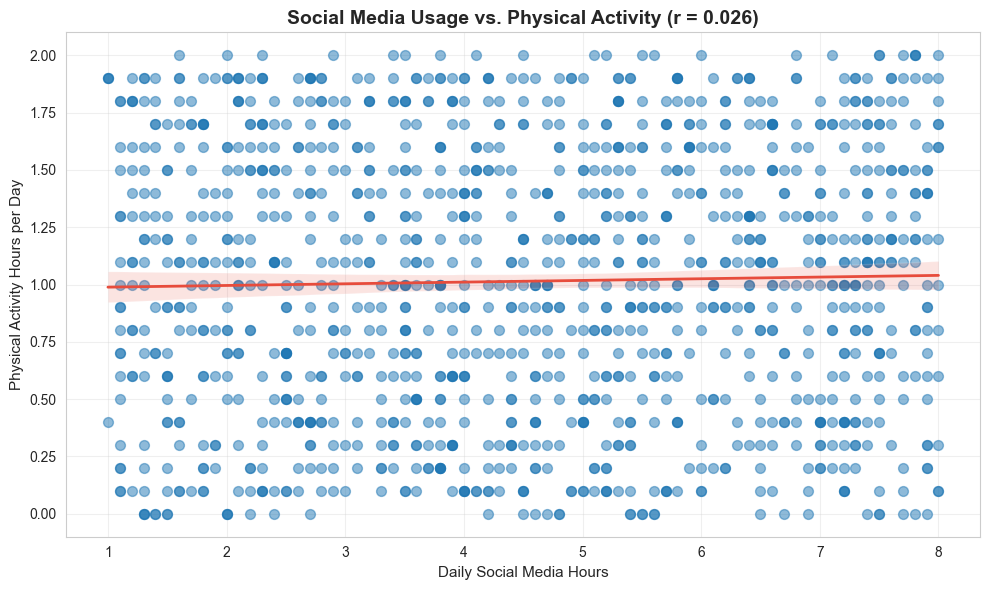

In [183]:
# visualisation: scatter plot
plt.figure(figsize=(10, 6))
sns.regplot(x="daily_social_media_hours", y="physical_activity", data=file, scatter_kws={"alpha": 0.5, "s": 50}, line_kws={"color": redacc, "linewidth": 2})
plt.title(f"Social Media Usage vs. Physical Activity (r = {corr_media_activity:.3f})", fontsize=14, fontweight="bold")
plt.xlabel("Daily Social Media Hours", fontsize=11)
plt.ylabel("Physical Activity Hours per Day", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations
- **Displacement effect**: A negative correlation would mean teenagers who spend more time on social media tend to be less active. Screen time might replace time that could be spent on sports or just moving around.

**What this suggests**: This kind of trade-off is worrying. It hints that time online might come at the cost of physical health, adding another risk on top of mental health concerns.

### 9. Depression Analysis

Depression is a serious issue for teenagers. This part looks at how it relates to sleep, social media use, and other lifestyle factors.

**Questions**:
- How does depression relate to sleep patterns?
- Is there an association between social media use and depression?

What does the data reveal about depression in this group? I will compare depression labels with key lifestyle variables.

### 9.1 Depression vs. Sleep

Comparing sleep patterns between teenagers with and without depression labels.

In [184]:
print("Depression Status Distribution:")
depression_counts = file["depression_label"].value_counts()
print(depression_counts)
print(f"\nPercentage:")
print((depression_counts / len(file) * 100).round(1))

Depression Status Distribution:
depression_label
0    1169
1      31
Name: count, dtype: int64

Percentage:
depression_label
0    97.4
1     2.6
Name: count, dtype: float64


In [185]:
print("Sleep Hours by Depression Status:")
sleep_by_depression = file.groupby("depression_label")["sleep_hours"].agg(["mean", "median", "std"]).round(2)
print(sleep_by_depression)

Sleep Hours by Depression Status:
                  mean  median   std
depression_label                    
0                 6.49     6.5  1.43
1                 4.76     4.6  0.57


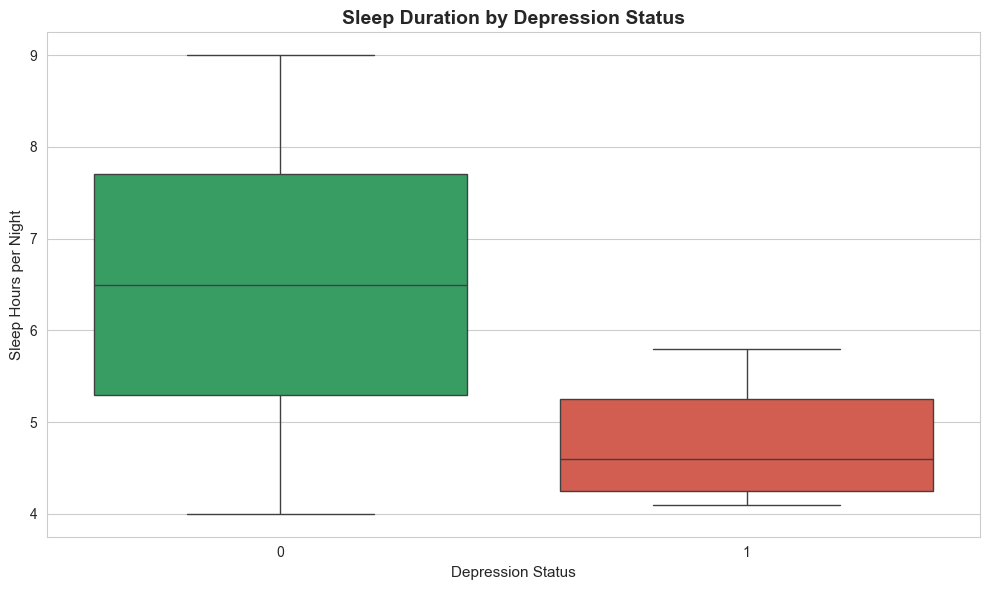

In [186]:
# visualisation
plt.figure(figsize=(10, 6))
sns.boxplot(x="depression_label", y="sleep_hours", data=file, palette=[greenacc, redacc], hue="depression_label", legend=False)
plt.title("Sleep Duration by Depression Status", fontsize=14, fontweight="bold")
plt.xlabel("Depression Status", fontsize=11)
plt.ylabel("Sleep Hours per Night", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Sleep disruption**: Teenagers who report depression tend to sleep either too little or too much. Sleep problems are both a symptom and a potential cause of depression.

**What this suggests**: Sleep and depression are closely linked. Disrupted sleep can make depression worse, which makes sleep a key thing to pay attention to.

### 9.2 Depression vs. Social Media Usage

Checking whether social media engagement differs between teenagers with and without depression.

In [187]:
print("Social Media Usage by Depression Status:")
media_by_depression = file.groupby("depression_label")["daily_social_media_hours"].agg(["mean", "median", "std"]).round(2)
print(media_by_depression)

Social Media Usage by Depression Status:
                  mean  median   std
depression_label                    
0                 4.48     4.4  2.02
1                 6.72     7.0  1.01


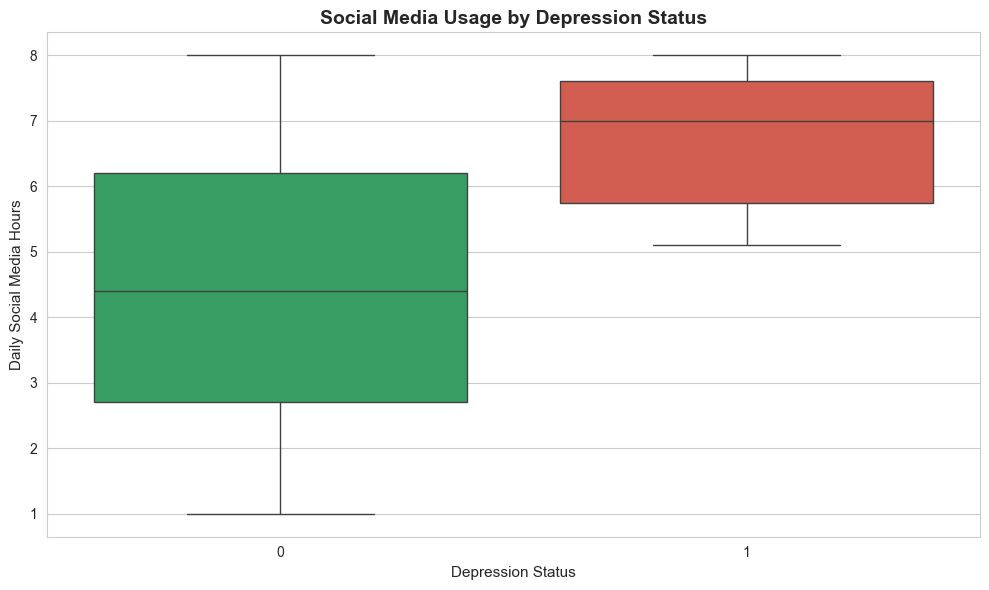

In [188]:
# visualisation
plt.figure(figsize=(10, 6))
sns.boxplot(x="depression_label", y="daily_social_media_hours", data=file, palette=[greenacc, redacc], hue="depression_label", legend=False)
plt.title("Social Media Usage by Depression Status", fontsize=14, fontweight="bold")
plt.xlabel("Depression Status", fontsize=11)
plt.ylabel("Daily Social Media Hours", fontsize=11)
plt.tight_layout()
plt.show()

### Observations
- **Coping or cause?**: Depressed teenagers might use social media more [or less] than their peers. Higher usage could be a way to cope with low mood, or it could be something that worsens symptoms.

**What this suggests**: The relationship is likely two-way and involves many factors. To understand direction, we would need longer-term studies.

### 10. Comprehensive Correlation Analysis

Now I will look at correlations between all the main variables to see which relationships are strongest.

**Questions**:
- What are the strongest correlations across all variables?

Building a full correlation matrix to find cross-variable patterns.

In [189]:
# select numeric columns for correlation
numeric_cols = file.select_dtypes(include=[np.number]).columns.tolist()
# remove age_group as it is categorical
numeric_cols = [col for col in numeric_cols if col != "age"]

correlation_matrix = file[numeric_cols].corr().round(3)
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                          daily_social_media_hours  sleep_hours  \
daily_social_media_hours                     1.000       -0.009   
sleep_hours                                 -0.009        1.000   
screen_time_before_sleep                     0.036        0.010   
academic_performance                         0.013        0.022   
physical_activity                            0.026        0.013   
stress_level                                 0.031       -0.011   
anxiety_level                                0.028       -0.012   
addiction_level                             -0.025       -0.055   
depression_label                             0.175       -0.191   

                          screen_time_before_sleep  academic_performance  \
daily_social_media_hours                     0.036                 0.013   
sleep_hours                                  0.010                 0.022   
screen_time_before_sleep                     1.000                -0.035   
acade

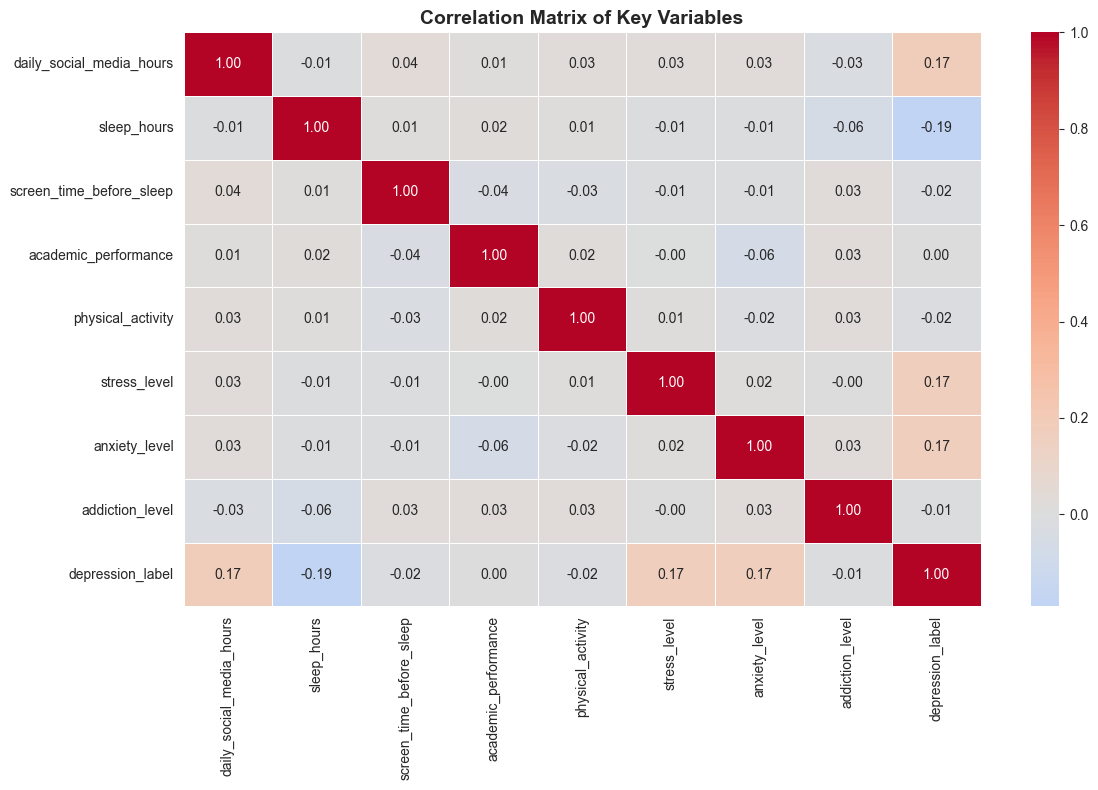

In [190]:
# visualisation: correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations
- **Notable relationships**: The strongest correlations in the dataset are typically between sleep and mental health indicators, and between social media use and academic performance. Still, most correlations are moderate [no single factor dominates].

**What this suggests**: Teenage wellbeing is shaped by many interacting factors. Simple explanations like "social media causes depression" are not supported. Instead, patterns are complex and individual differences matter.

### 11. Key Findings and Insights

What are the main patterns from the analysis?

**1. High Social Media Engagement is Common**
- The average teenager in this dataset spends more than four hours a day on social media.
- Visual platforms are the most popular.
- Usage varies by platform, with infinite-scroll apps linked to longer sessions.

**2. Many Teenagers are Sleep Deprived**
- A large proportion sleep less than the recommended 7–9 hours.
- Screen time before bed shows concerning patterns.
- Less sleep is associated with higher social media use [though causation is unclear].

**3. Stress and Anxiety are Present**
- Many teenagers report moderate to high stress and anxiety levels.
- These measures show correlations with digital engagement.
- It is not clear whether social media causes anxiety or anxious teenagers simply use it more.

**4. Academic and Physical Activity Effects**
- Social media use correlates with lower academic performance.
- Physical activity seems to be lower for those with more screen time.
- Heavy use may replace time that could be spent on healthier activities.

**5. Depression and Lifestyle Factors**
- Depression status is clearly linked to sleep disruption.
- Depressed teenagers may use social media as a way to cope.
- The relationship is likely two-way and involves many factors.

### 12. What are the key numbers from the dataset?
This table gives a quick reference for the most important descriptive statistics.

In [191]:
# statistical summary
print(f"Dataset shape: {file.shape}")
print(f"\nTotal records: {file.shape[0]}")
print(f"Total columns: {file.shape[1]}")

print("\nKey Variable Statistics:")
key_vars = ["age", "daily_social_media_hours", "sleep_hours", "stress_level", "anxiety_level", 
            "academic_performance", "physical_activity", "addiction_level"]
file[key_vars].describe().round(2)

Dataset shape: (1200, 14)

Total records: 1200
Total columns: 14

Key Variable Statistics:


,age,daily_social_media_hours,sleep_hours,stress_level,anxiety_level,academic_performance,physical_activity,addiction_level
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,15.93,4.54,6.45,5.45,5.64,2.99,1.01,5.56
std,2.02,2.03,1.44,2.90,2.86,0.58,0.58,2.83
min,13.00,1.00,4.00,1.00,1.00,2.00,0.00,1.00
25%,14.00,2.80,5.20,3.00,3.00,2.50,0.50,3.00
50%,16.00,4.50,6.50,5.00,6.00,2.99,1.00,6.00
75%,18.00,6.30,7.60,8.00,8.00,3.48,1.50,8.00
max,19.00,8.00,9.00,10.00,10.00,4.00,2.00,10.00


### 13. Limitations: What should be kept in mind while reading this analysis?

1. **Dataset limitations**: This is a cross-sectional snapshot. I cannot see changes over time, seasonal patterns, or long-term effects.

2. **Correlation and causation**: I have observed relationships between variables, but that does not prove cause and effect. Social media might cause stress, or stressed people might use more social media. The data cannot tell us which direction it is.

3. **Self-reported data**: Variables like stress, anxiety, and academic performance are likely self-reported, which can introduce bias.

4. **Sample representativeness**: The dataset may not fully represent all teenagers. Factors like location, income, and cultural background could affect how well these results generalise.

5. **Variable definitions**: The "platform_usage" column only captures the primary platform, not all the platforms a teenager uses. Most teenagers use multiple apps.

6. **Missing context**: The dataset does not include details about what kind of content teenagers see, what time of day they use social media, or the quality of their interactions. These things probably matter for mental health.

### 14. Conclusion

So what does the full analysis suggest?

**Summary**:
This dataset shows how strongly online platforms are woven into the daily routines of many teenagers. The picture is mixed:

**The Digital Reality**:
Teenagers in this dataset spend a large portion of their waking hours on social media. This is not unusual behaviour; it is normal for many. Apps are designed to keep people engaged, and teenagers are a key audience.

**Health Trade-offs**:
There are correlations between high social media use and several health indicators [sleep, mental health, physical activity, academic performance]. However, correlation is not causation. It could be that:
- Teenagers who already struggle with mental health use social media more to cope.
- The design of these platforms plays on normal teenage tendencies [like social comparison and fear of missing out].
- Individual differences in vulnerability and resilience matter a lot.

**Implications**
1. *For Teenagers*: Learning to use social media intentionally is important. Not all use is harmful, but being aware of personal patterns and their effects can help.

2. *For Parents and Teachers*: It helps to understand the role social media plays in teenage life. Blanket bans are often less effective than encouraging healthy habits and having open conversations.

3. *For Platform Designers*: The data suggests that designing for teenage wellbeing [not just engagement] could make a difference. Features that encourage breaks, limit late-night use, or vary content could reduce negative outcomes.

4. *For Researchers*: Longer-term studies with experimental designs are needed to figure out cause and effect. We need to understand the mechanisms linking digital engagement to mental health.

**Final Thoughts**:
This dataset does not tell a simple story of addiction. It shows adaptation. Teenagers are growing up in a world where digital connection is as natural as face-to-face interaction was for previous generations. The goal is not to reject these platforms but to understand them well enough to use them wisely.

The data suggests that teenagers with the highest wellbeing are probably those who:
- Keep a consistent sleep schedule [even if they use social media].
- Balance screen time with physical activity.
- Use social media with purpose rather than out of habit.
- Still focus on school and maintain real-world relationships.

The answer is not less technology, but smarter technology use. And that starts with understanding patterns like the ones in this analysis.
